In [1]:
import torch
from deepinv.physics import MRI, GaussianNoise
from deepinv.physics.generator import GaussianMaskGenerator
from deepinv.datasets import FastMRISliceDataset
from deepinv.utils import plot
from deepinv.sampling import DPSDataFidelity, PosteriorDiffusion, EulerSolver, VarianceExplodingDiffusion, DiffPIR, DPS
from deepinv.optim.data_fidelity import L2
from deepinv.loss.metric import LPIPS, PSNR
device = torch.device("cuda")
seed = 42

In [2]:
def normalize(x):
    "Project x in the [0, 1] range."
    return (x - x.min())/(x.max() - x.min())

def reconstruct_dps(y, physics, denoiser, niter=300, x_init=None, device='cpu'):
    model = PosteriorDiffusion(data_fidelity=DPSDataFidelity(denoiser), denoiser=denoiser,
                               sde=VarianceExplodingDiffusion(sigma_max=20, sigma_min=0.02, alpha=0.5, device=device,),
                               solver=EulerSolver(timesteps=torch.linspace(1, 0.001, niter, device=device)), device=device, verbose=True)
    return model(y=y, physics=physics, seed=seed,  x_init=x_init)


In [3]:
# loading models
model_brain = torch.load("models/diffusion/brain.pth", weights_only=False).to(device)
model_knee = torch.load("models/diffusion/knee.pth", weights_only=False).to(device)

class InputWrapper(torch.nn.Module):  # wrapper class to use deepinv MRI 
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model.to(device)

    def forward(self, x, scalar):
        extra = x[:, :1]  # extract the real part
        respart = self.base_model(extra, scalar)
        res = torch.zeros([1, 2, 320, 320], device=extra.device)
        res[:, 0] = respart
        return res
        
model_brain = InputWrapper(model_brain)
model_knee = InputWrapper(model_knee)

In [4]:
# load datasets
knee_ds = FastMRISliceDataset("datasets/mri/knee")
brain_ds = FastMRISliceDataset("datasets/mri/brain")
img_size = 320

100%|██████████| 114/114 [00:00<00:00, 721.11it/s]


In [5]:
# load a random mask
R = 6  # acceleration factor
mask_gen = GaussianMaskGenerator(acceleration=R, img_size=(img_size,img_size))
mask = mask_gen.step()["mask"].to(device)

sigma = 0.1  # noise level

In [6]:
# create physics
physics = MRI(mask=mask, img_size=(320, 320), device=device, noise_model=GaussianNoise(sigma))

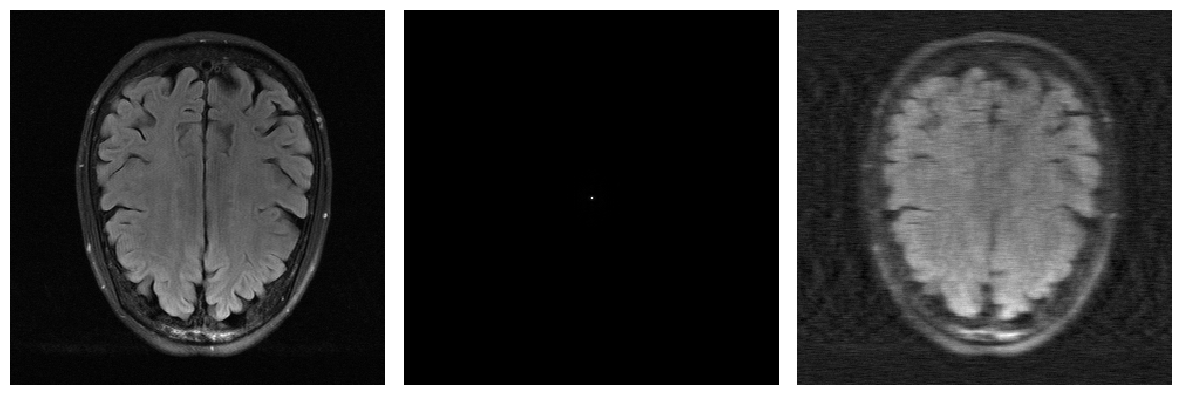

In [8]:
# pull one sample from the dataset and generate measurements
x = torch.zeros([1, 2, 320, 320]).to(device)
x[:, 0] = 2*normalize(brain_ds[20][0])-1 #  normalization for denoiser
y = physics(x)
plot([x[:, 0], y, physics.A_adjoint(y)[:, 0]], figsize=(15, 5))


In [18]:
x_init = torch.zeros([1, 2, 320, 320], device=device)
x_init[:, 0] = 2*normalize(physics.A_adjoint(y)[:, 0])-1
x_rec = reconstruct_dps(y=y, physics=physics, denoiser=model_brain, x_init=x_init, niter=300, device=device)
x_rec2 = reconstruct_dps(y=y, physics=physics, denoiser=model_knee, x_init=x_init, niter=300, device=device)


/linkhome/rech/gendho01/uaq36gg/.local/lib/python3.12/site-packages/deepinv/sampling/sde_solver.py:159: UserWarning: Cannot set seed for random number generator because it is not initialized. The `seed` parameter is ignored.
  warnings.warn(
100%|██████████| 299/299 [01:58<00:00,  2.52it/s]


Loading pretrained model LPIPS from /linkhome/rech/gendho01/uaq36gg/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth


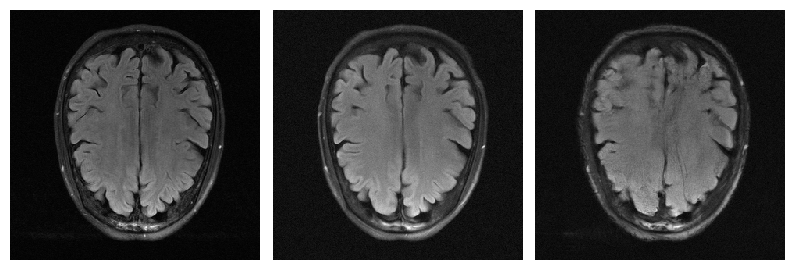

23.258357261881994 22.543636715617147
tensor([0.0892]) tensor([0.1414])


In [19]:
psnr, lpips = PSNR(), LPIPS()
psnr1, psnr2 = psnr(x_rec[:, :1], x[:, :1]), psnr(x_rec2[:, :1], x[:, :1])
lpips1, lpips2 = lpips(x_rec[:, :1].float(), x[:, :1]), lpips(x_rec2[:, :1].float(), x[:, :1])

plot([x[:, 0] ,x_rec[:, 0], x_rec2[:, 0]], figsize=(10, 5))
print(psnr1.item(), psnr2.item())
print(lpips1, lpips2)

/tmp/ipykernel_1775335/116515851.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x[:, 0] = normalize(torch.tensor(brain_ds[20][0]))  # in 0,1


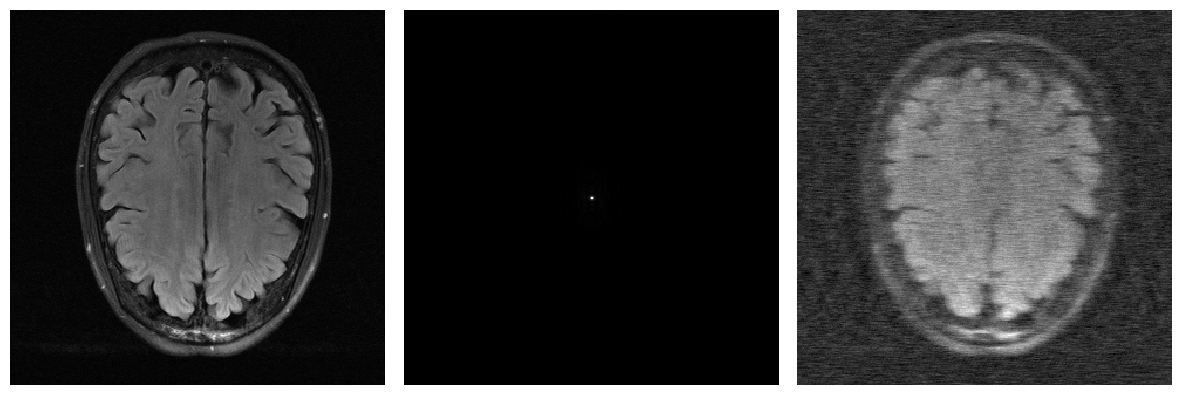

In [20]:
# pull one sample from the dataset and generate measurements
x = torch.zeros([1, 2, 320, 320]).to(device)
x[:, 0] = normalize(torch.tensor(brain_ds[20][0]))  # in 0,1
y = physics(x)
#y = y + torch.randn_like(y)*sigma
plot([x[:, 0], y, physics.A_adjoint(y)[:, 0]], figsize=(15, 5))

In [21]:
denoiser = torch.load("models/diffusion/brain.pth", weights_only=False).to(device)

class InputWrapper2(torch.nn.Module):  # wrapper class to use deepinv MRI 
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model.to(device)

    def forward(self, x, scalar):
        extra = 2*normalize(x[:, :1]) -1 # extract the real part
        respart = normalize(self.base_model(extra, scalar))
        res = torch.zeros([1, 2, 320, 320], device=extra.device)
        res[:, 0] = respart
        return res
denoiser = InputWrapper2(denoiser)  

model = DPS(data_fidelity=L2(),
                 model=denoiser,
                device=device, verbose=True, max_iter=200)

100%|██████████| 200/200 [00:52<00:00,  3.82it/s]


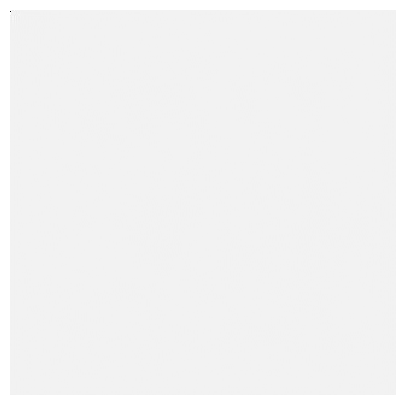

In [22]:
x_rec = model(y=y, physics=physics, seed=0)
plot(x_rec[:, 0], figsize=(10,5))

100%|██████████| 200/200 [00:28<00:00,  7.04it/s]


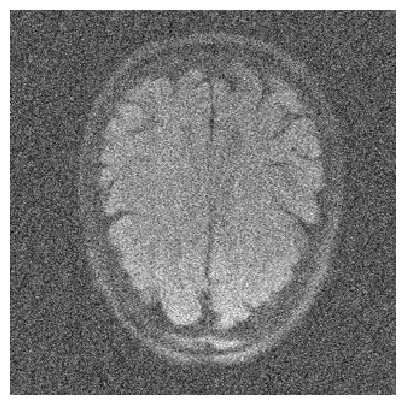

In [23]:
model = DiffPIR(data_fidelity=L2(),
                 model=denoiser,
                device=device, verbose=True, max_iter=200)
x_rec = model(y=y, physics=physics, seed=0)
plot(x_rec[:, 0], figsize=(10,5))